In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_sauvola

In [2]:
DATA_PATH = "/kaggle/input/brain-tumor-segmentation"

images_path = os.path.join(DATA_PATH, "images")
masks_path  = os.path.join(DATA_PATH, "masks")

image_list = sorted(os.listdir(images_path))
mask_list  = sorted(os.listdir(masks_path))

print("Total Images:", len(image_list))

Total Images: 3064


# METRIC FUNCTIONS

In [3]:

def calculate_dice(pred, true):
    inter = np.sum(pred * true)
    return (2.0 * inter) / (np.sum(pred) + np.sum(true) + 1e-8)

def calculate_jaccard(pred, true):
    inter = np.sum(pred * true)
    union = np.sum(pred) + np.sum(true) - inter
    return inter / (union + 1e-8)

PROCESS IMAGES

In [8]:

dice_otsu_all = []
dice_sauvola_all = []

jaccard_otsu_all = []
jaccard_sauvola_all = []


NUM_SAMPLES = 100

for i in range(NUM_SAMPLES):

    img = cv2.imread(os.path.join(images_path, image_list[i]), 0)
    mask = cv2.imread(os.path.join(masks_path, mask_list[i]), 0)

    img = cv2.resize(img, (256, 256))
    mask = cv2.resize(mask, (256, 256))

    mask_binary = (mask > 0).astype(np.uint8)

    smoothed_img = cv2.GaussianBlur(img, (5,5), 0)
    
    # ----- OTSU (Global Threshold) -----
    _, otsu_segment = cv2.threshold(
        smoothed_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    otsu_binary = (otsu_segment > 0).astype(np.uint8)
    
    # ----- SAUVOLA (Adaptive Threshold) -----
    window_size = 25
    sauvola_threshold = threshold_sauvola(smoothed_img, window_size=window_size)
    sauvola_binary = (smoothed_img > sauvola_threshold).astype(np.uint8)
    
   


Compute Metrics

In [9]:
    dice_otsu_all.append(calculate_dice(otsu_binary, mask_binary))
    dice_sauvola_all.append(calculate_dice(sauvola_binary, mask_binary))
    
    jaccard_otsu_all.append(calculate_jaccard(otsu_binary, mask_binary))
    jaccard_sauvola_all.append(calculate_jaccard(sauvola_binary, mask_binary))

In [10]:
print("\n========== FINAL AVERAGE RESULTS ==========")

print("Otsu     -> Dice:", np.mean(dice_otsu_all))
print("Otsu     -> Jaccard:", np.mean(jaccard_otsu_all))

print("Sauvola  -> Dice:", np.mean(dice_sauvola_all))
print("Sauvola  -> Jaccard:", np.mean(jaccard_sauvola_all))


========== FINAL AVERAGE RESULTS ==========
Otsu     -> Dice: 0.04984923333545588
Otsu     -> Jaccard: 0.02556173306575466
Sauvola  -> Dice: 0.026978994925373753
Sauvola  -> Jaccard: 0.013673952206278369


VISUALIZE IMAGE

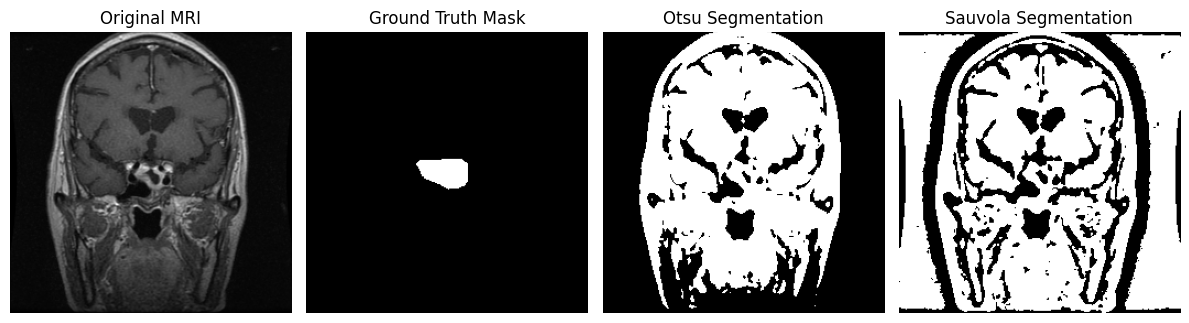

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("Original MRI")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Ground Truth Mask")
plt.imshow(mask_binary, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Otsu Segmentation")
plt.imshow(otsu_binary, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Sauvola Segmentation")
plt.imshow(sauvola_binary, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

